## Ridge Regression

### Import Required Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Importing the Dataset

In [3]:
df = pd.read_csv("C:\\Users\\subham\\Desktop\\TekWorks\\Regularization\\overfitting_dataset.csv")
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,0.491200,-0.101731,0.767435,-0.469474,0.542560,...,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,9.247606
1,1.465649,-0.225776,0.067528,-1.424748,-0.544383,1.120915,-0.090561,0.375698,-0.600639,-0.291694,...,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,7.078892
2,0.738467,0.171368,-0.115648,-0.301104,-1.478522,0.600385,0.007686,1.057122,0.343618,-1.763040,...,-0.385082,-0.676922,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545,1.968053
3,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,-0.429567,-0.091720,1.003533,0.361636,-0.645120,...,1.538037,-0.035826,1.564644,-2.619745,0.821903,0.087047,-0.299007,0.091761,-1.987569,-1.963242
4,-0.219672,0.357113,1.477894,-0.518270,-0.808494,-0.219187,0.266624,0.328751,-0.529760,0.513267,...,0.968645,-0.702053,-0.327662,-0.392108,-1.463515,0.296120,0.261055,0.005113,-0.234587,2.149874


### Check the statistical summary

In [6]:
df.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,...,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.029524,-0.003657,-0.084381,0.068184,-0.184437,0.033525,0.012279,0.048772,-0.114112,-0.048619,...,0.053765,-0.037094,0.102206,0.256272,-0.080032,-0.013218,-0.074742,0.110347,0.053978,0.947147
std,0.989348,0.999557,1.206141,1.017490,0.947201,0.797209,0.703429,0.961052,0.920906,1.128897,...,1.129215,0.813387,1.023107,1.206247,0.956172,0.869004,0.779173,0.988708,0.955621,6.716026
min,-1.840874,-1.867265,-3.241267,-1.612716,-2.471645,-1.572535,-1.362633,-1.430141,-2.650970,-1.763040,...,-2.301921,-1.534114,-1.913280,-2.619745,-2.211135,-2.025143,-1.959670,-1.703382,-1.987569,-14.022067
25%,-0.790986,-0.663834,-0.732813,-0.608138,-0.760164,-0.543089,-0.493834,-0.778998,-0.554979,-0.774334,...,-0.625803,-0.611254,-0.723192,-0.595538,-0.722885,-0.775432,-0.396556,-0.502435,-0.567016,-3.752527
50%,0.145609,-0.087131,-0.070757,0.115807,-0.239948,0.127428,-0.040998,-0.020851,0.052123,-0.252570,...,0.021025,-0.024662,0.294041,0.312693,-0.063027,0.050488,-0.107232,0.080781,0.048637,0.260794
75%,0.649669,0.569378,0.701519,0.643755,0.528192,0.502685,0.352265,0.703916,0.407121,0.564006,...,1.001178,0.347259,0.822533,1.032635,0.562662,0.495218,0.308287,0.563972,0.751524,5.760771
max,2.314659,2.075401,2.560085,2.270693,2.133033,1.807754,1.518635,1.896793,1.765454,3.852731,...,1.852278,2.122156,2.463242,2.573360,2.632382,1.865775,1.752270,3.078881,2.720169,19.562157


In [7]:
df.isnull().sum()

feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
target        0
dtype: int64

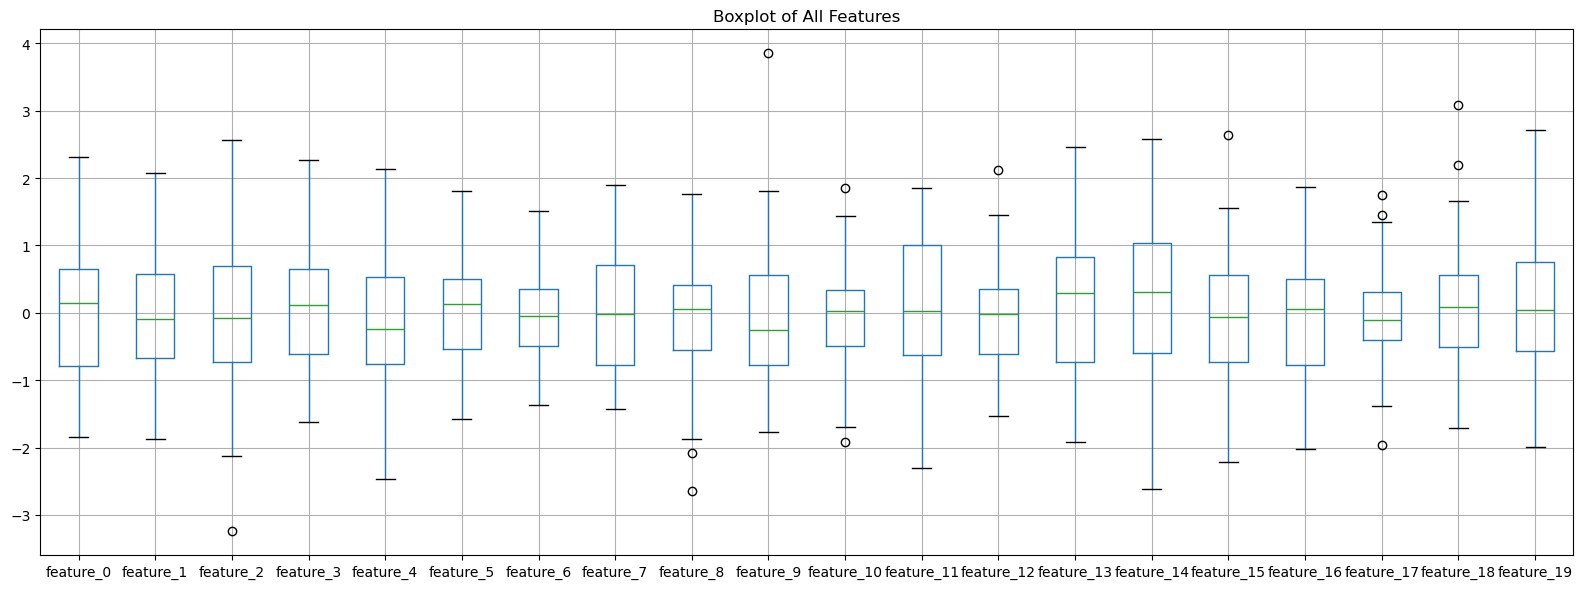

In [11]:
# boxplot all columns (excluding target)
df.drop('target', axis=1).boxplot(figsize=(16, 6))
plt.title('Boxplot of All Features')
plt.tight_layout()
plt.show()

In [12]:
# divide data into train and test and select model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 12.537680948525123
R^2 Score: 0.7316351590907735


In [13]:
print("Training Score:", model.score(X_train, y_train))
print("Testing Score:", model.score(X_test, y_test))

Training Score: 0.9681257749341244
Testing Score: 0.7316351590907735


In [20]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=0.001)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f'Ridge Mean Squared Error: {mse_ridge}')
print(f'Ridge R^2 Score: {r2_ridge}')

Ridge Mean Squared Error: 12.220202036389164
Ridge R^2 Score: 0.7384306883515036


### Lasso Regression (L1 Regularization)

In [21]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f'Lasso Mean Squared Error: {mse_lasso}')
print(f'Lasso R^2 Score: {r2_lasso}')


Lasso Mean Squared Error: 12.607135100334343
Lasso R^2 Score: 0.7301485163474073
